In [1]:
#!pip install kagglehub==1.0.0 -q

In [1]:
import os

path = None

if os.path.exists("../data/raw"):
    path = "../data/raw"
else:
    # login in a different cell to avoid a known kagglehub issue
    import kagglehub
    kagglehub.login()
    #KGAT_711ad5fd816c7a6fbb583a8baa9ecc15

In [3]:
if path is None:
    # do not forget to enter the Kaggle competition through the link in the project statement (section 4)
    path = kagglehub.competition_download('aca-tp-2')
    print("Path to dataset files:", path)

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [6]:
import sys

sys.path.append(os.path.abspath('..'))

from src.baseline.model import BaselineCNN
from src.utils.data_loader import ButterflyDataset

In [7]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


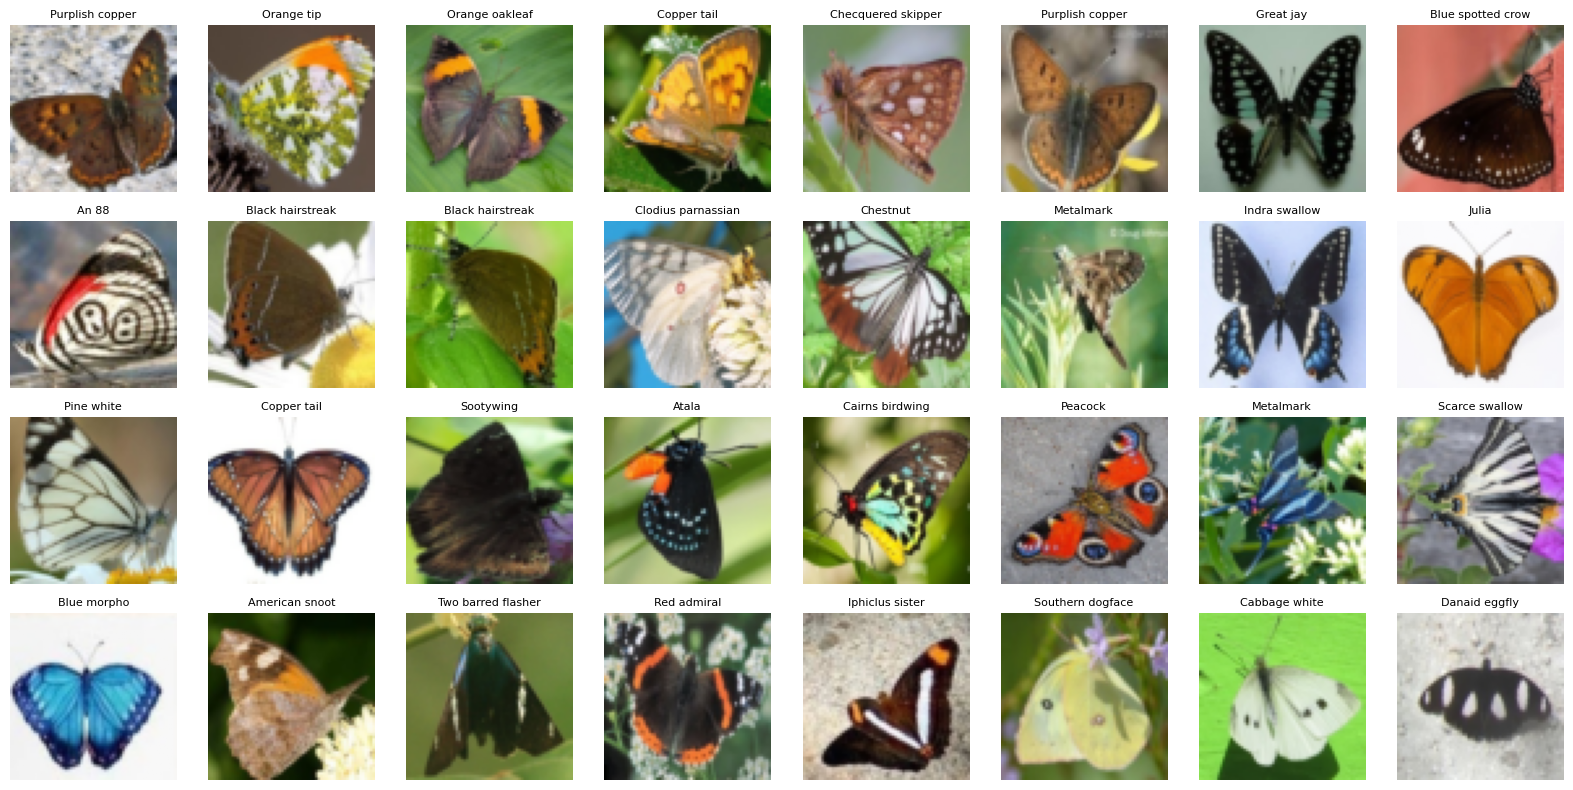

In [9]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Data Split

In [16]:
from src.utils.data_split import create_save_data_split
create_save_data_split(df, output_dir='splits')


Created and saved data splits.


In [ ]:
# Este bloco é preciso colocar sempre que quisermos usar os splits
BATCH_SIZE = 32
IMAGE_SIZE = 64

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

img_dir = os.path.join(path, 'train')
#df = pd.read_csv(os.path.join(path, 'train.csv'))
#dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
#dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

full_train_df = pd.read_csv('splits/full_train_split.csv')
train_df = pd.read_csv('splits/train_split.csv')
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')

train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

full_train_dataset = ButterflyDataset(df=full_train_df, img_dir=img_dir, transform=data_transform)
full_train_dataloader = data.DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
full_train_df.head()

,filename,label
0,Image_300.jpg,PURPLE HAIRSTREAK
1,Image_2526.jpg,SLEEPY ORANGE
2,Image_4741.jpg,MONARCH
3,Image_1866.jpg,GREAT EGGFLY
4,Image_4330.jpg,SILVER SPOT SKIPPER


In [31]:
full_train_df.describe()

,filename,label
count,4159,4159
unique,4159,75
top,Image_300.jpg,MOURNING CLOAK
freq,1,84


In [38]:
import matplotlib.cm as cm
def plot_class_distribution(df, title, label_column="label"):
    class_counts = df[label_column].value_counts()
    num_classes = len(class_counts)
    colors = cm.viridis(range(num_classes))

    plt.figure(figsize=(15, 6))
    plt.bar(class_counts.index, class_counts.values, color=colors)
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Classes / Espécies", fontsize=12)
    plt.ylabel("Número de Imagens", fontsize=12)
    
    plt.xticks(rotation=90, ha="right", fontsize=9)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.show()

Number of samples: 4159
Number of classes: 75


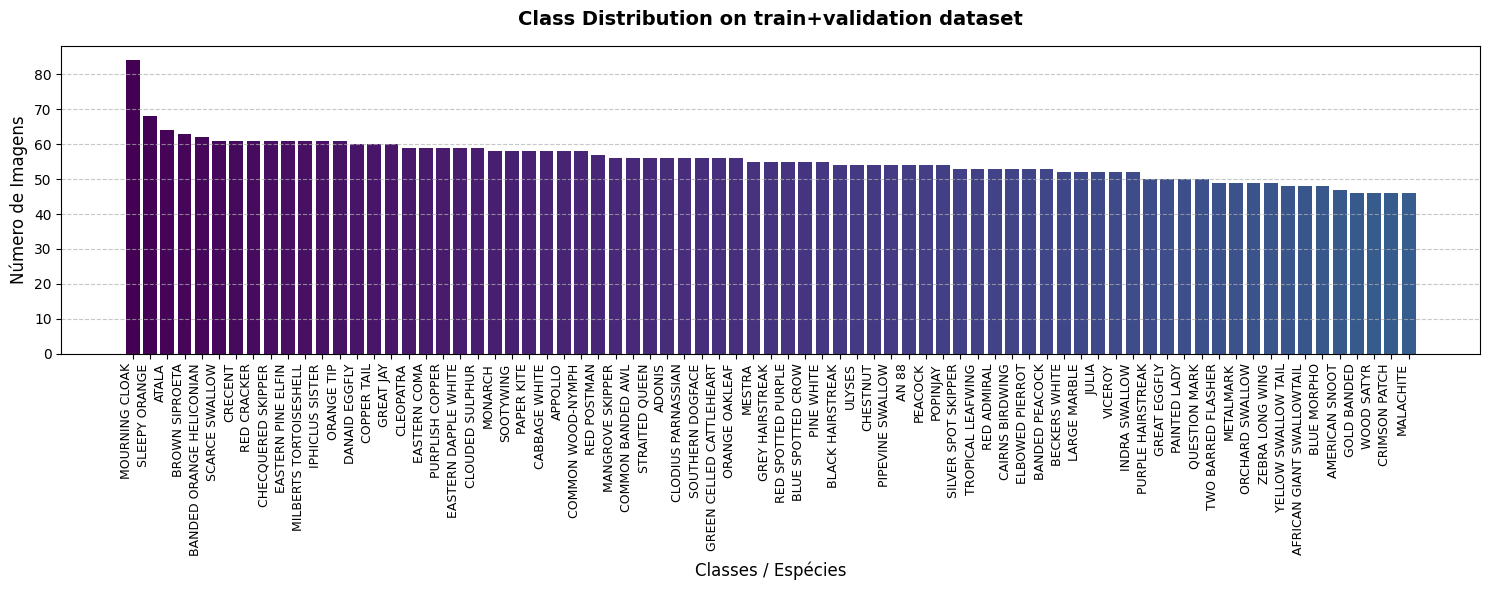

In [39]:
# Full train dataset (train+val)
print(f"Number of samples: {len(full_train_df)}")
print(f"Number of classes: {len(full_train_df["label"].unique())}")

plot_class_distribution(full_train_df, "Class Distribution on train+validation dataset")

In [75]:
# How many images to generate?
class_counts = df["label"].value_counts()

max_images = class_counts[:1]
max_images_class = max_images.index.to_numpy()
max_images_counts = max_images.values[0]
print(max_images_class)
print(max_images_counts)

smaller_classes_df = class_counts[-5:]
smaller_classes = smaller_classes_df.index.to_numpy()
smaller_counts = smaller_classes_df.values
print(smaller_classes)
print(smaller_counts)

missing_images = [int(max_images_counts - i) for i in smaller_counts]
print(missing_images)
missing_images_dic = dict(zip(smaller_classes, missing_images))
print(missing_images_dic)

['MOURNING CLOAK']
105
['AMERICAN SNOOT' 'CRIMSON PATCH' 'MALACHITE' 'GOLD BANDED' 'WOOD SATYR']
[59 58 58 58 57]
[46, 47, 47, 47, 48]
{'AMERICAN SNOOT': 46, 'CRIMSON PATCH': 47, 'MALACHITE': 47, 'GOLD BANDED': 47, 'WOOD SATYR': 48}


Number of samples: 3160
Number of classes: 75


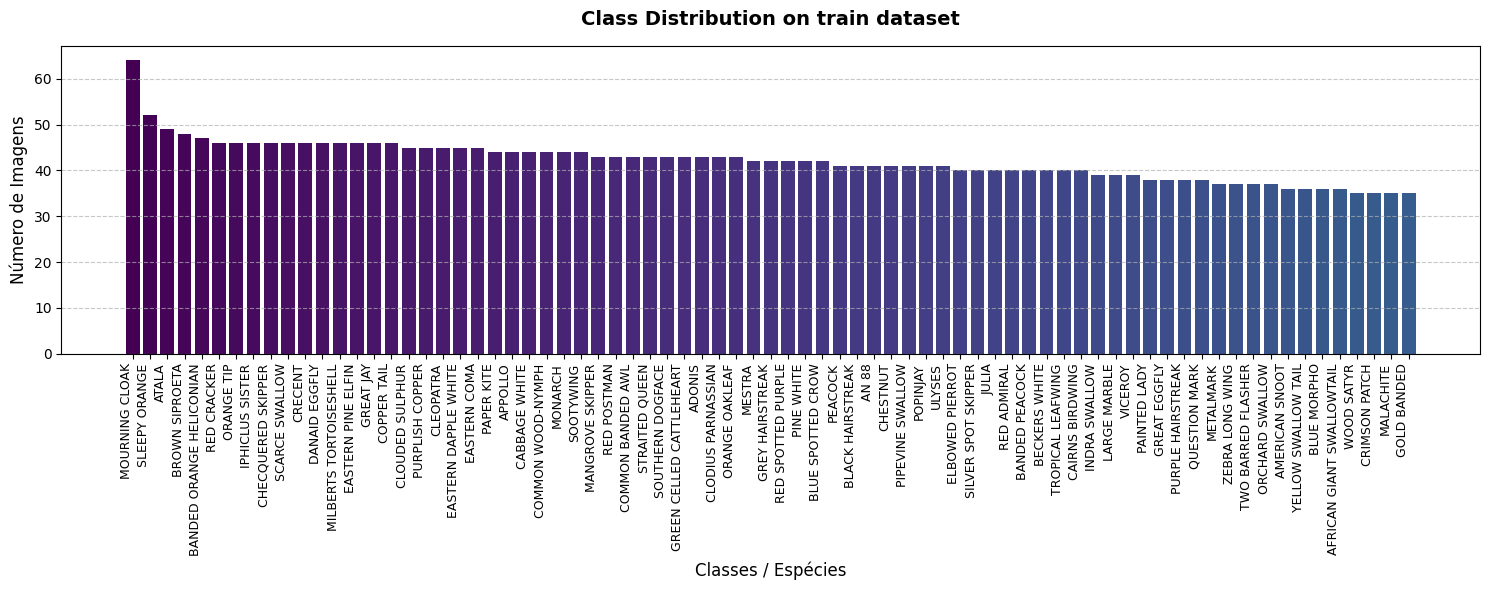

In [76]:
# Train dataset
print(f"Number of samples: {len(train_df)}")
print(f"Number of classes: {len(train_df["label"].unique())}")

plot_class_distribution(train_df, "Class Distribution on train dataset")

Number of samples: 999
Number of classes: 75


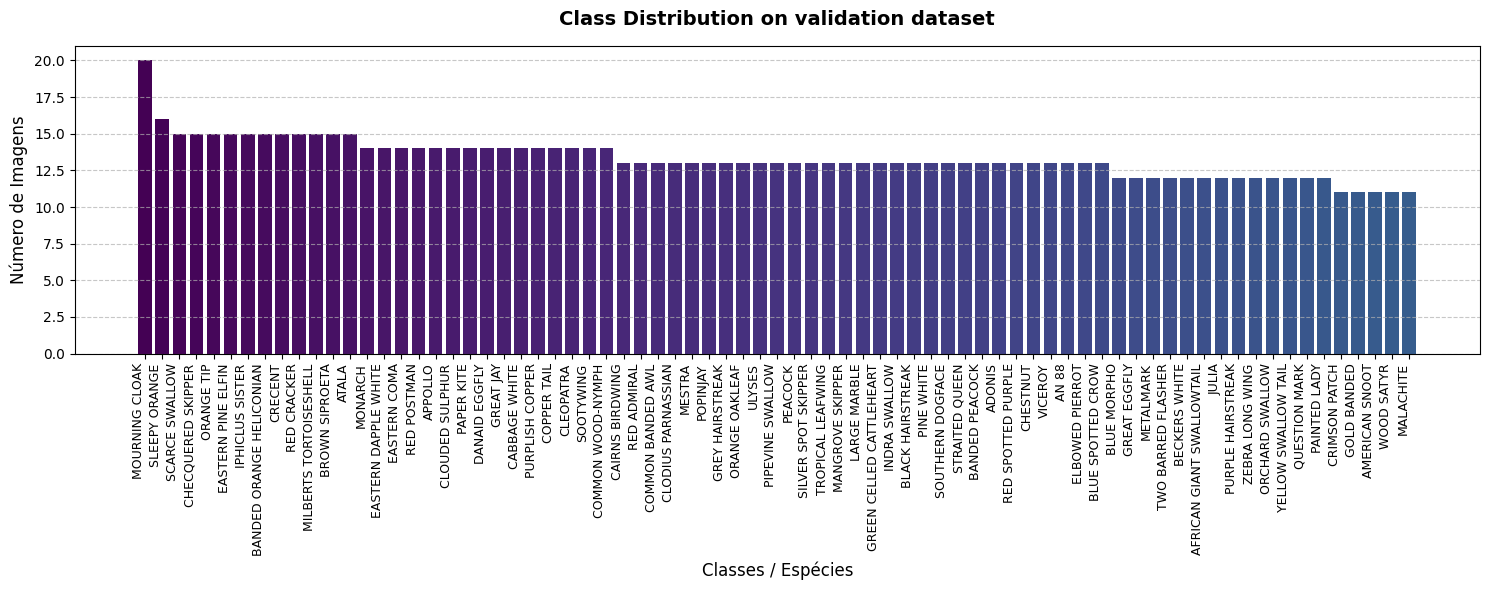

In [77]:
# Val dataset
print(f"Number of samples: {len(val_df)}")
print(f"Number of classes: {len(val_df["label"].unique())}")
plot_class_distribution(val_df, "Class Distribution on validation dataset")

Number of samples: 1040
Number of classes: 75


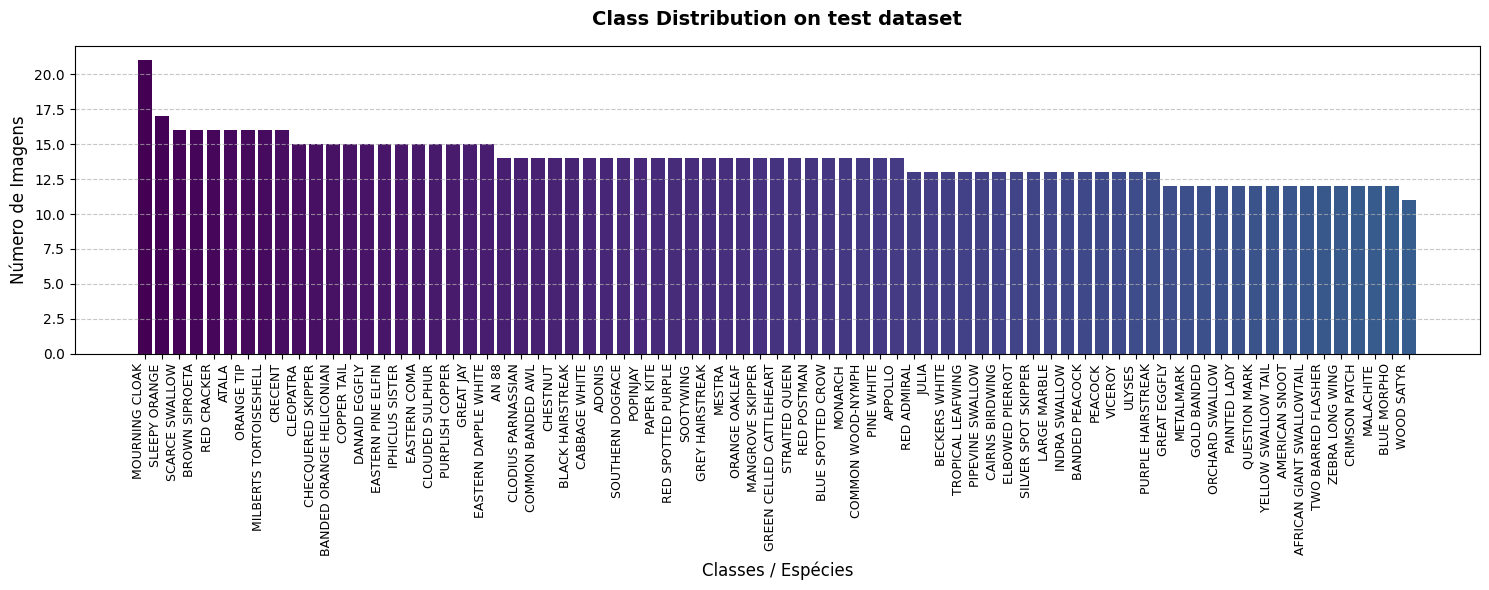

In [78]:
# Test dataset
print(f"Number of samples: {len(test_df)}")
print(f"Number of classes: {len(test_df["label"].unique())}")
plot_class_distribution(test_df, "Class Distribution on test dataset")